# Notebook 3 — Estadística Inferencial

## Diplomado de Técnicas Estadísticas — Módulo II

**Alumno:** Cristopher Carlos García  
**Módulo:** II — Probabilidad y Simulación  
**Tema:** Estimadores puntuales, Método de Momentos, Máxima Verosimilitud, Propiedades de los estimadores e Intervalos de Confianza  
**Fecha:** Junio 2026

---

En este notebook abordamos la **Estadística Inferencial**, cuyo objetivo es usar la información
de una **muestra** para hacer afirmaciones sobre un **parámetro poblacional desconocido**
(por ejemplo la media $\mu$, la varianza $\sigma^2$ o una proporción $p$).

Estudiaremos:

1. **Estimadores puntuales** — qué son y cómo se interpretan.
2. **Método de los momentos** — con ejemplos resueltos (Exponencial y Normal).
3. **Estimación por Máxima Verosimilitud (EMV)** — con optimización numérica y gráficas.
4. **Propiedades de los estimadores** — insesgadez, consistencia y eficiencia (con simulaciones).
5. **Intervalos de confianza** — para la media ($\sigma$ conocida y desconocida) y para una proporción.
6. **Cobertura de los intervalos de confianza** — demostración visual con 100 muestras.


## 0. Librerías utilizadas

Cargamos las librerías de trabajo. Usamos `scipy.stats` para las distribuciones teóricas,
`scipy.optimize` para maximizar numéricamente la log-verosimilitud y `sympy` para algún
cálculo simbólico. Fijamos una **semilla** para reproducibilidad.


In [1]:
# Importamos las librerías necesarias
import numpy as np                        # cálculo numérico y generación de aleatorios
import matplotlib.pyplot as plt           # gráficas
import scipy.stats as st                  # distribuciones de probabilidad teóricas
from scipy.optimize import minimize       # optimización numérica (para la EMV)

# Fijamos la semilla para reproducibilidad de las simulaciones
np.random.seed(42)

# Estilo general de las gráficas
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Estimadores puntuales

### ¿Qué es un estimador?

Supongamos que tenemos una muestra aleatoria $X_1, X_2, \dots, X_n$ proveniente de una
distribución que depende de un **parámetro desconocido** $\theta$ (por ejemplo, la media $\mu$).

Un **estimador puntual** es una función de la muestra

$$\hat{\theta} = T(X_1, X_2, \dots, X_n)$$

que nos da un **único valor numérico** como "mejor adivinanza" del parámetro $\theta$.

**En lenguaje claro:** un estimador es una *regla o fórmula* que aplicamos a los datos para
obtener un número que aproxima al valor real (y desconocido) del parámetro poblacional.
Como depende de la muestra, el estimador es a su vez una **variable aleatoria**: si tomáramos
otra muestra, obtendríamos un valor ligeramente distinto.

### Ejemplo clásico: la media muestral

El estimador más usado del parámetro poblacional $\mu$ es la **media muestral**:

$$\hat{\mu} = \bar{X} = \frac{1}{n}\sum_{i=1}^{n} X_i$$

Veamos un ejemplo numérico.


In [2]:
# Población: normal con media verdadera mu = 50 y desviación sigma = 8
mu_verdadera = 50
sigma_verdadera = 8

# Tomamos una muestra aleatoria de tamaño n = 30
n = 30
muestra = np.random.normal(mu_verdadera, sigma_verdadera, n)

# El estimador puntual de mu es la media muestral
mu_estimada = np.mean(muestra)

print(f"Parámetro verdadero  mu = {mu_verdadera}")
print(f"Estimador puntual  x̄ = {mu_estimada:.4f}")
print(f"Error de estimación   = {abs(mu_estimada - mu_verdadera):.4f}")

Parámetro verdadero  mu = 50
Estimador puntual  x̄ = 48.4948
Error de estimación   = 1.5052


**Interpretación:** con una sola muestra de tamaño $n=30$ obtenemos un valor cercano —pero no
idéntico— a la media verdadera. El estimador $\bar{X}$ nos da nuestra mejor aproximación puntual
del parámetro $\mu$ con la información disponible.


## 2. Método de los momentos

### Principio

El **método de los momentos** es una técnica sencilla para obtener estimadores. La idea es:

> **Igualar los momentos poblacionales (teóricos) con los momentos muestrales (empíricos)**
> y resolver para los parámetros.

El $k$-ésimo **momento poblacional** es $E(X^k)$ y el $k$-ésimo **momento muestral** es
$m_k = \frac{1}{n}\sum_{i=1}^n X_i^k$.

Para un parámetro se usa el primer momento; para dos parámetros se usan los dos primeros, etc.

$$E(X) = \frac{1}{n}\sum_{i=1}^n X_i, \qquad E(X^2) = \frac{1}{n}\sum_{i=1}^n X_i^2, \qquad \dots$$


### Ejemplo 1 — Distribución Exponencial

Para la distribución **Exponencial** con parámetro $\lambda$ se cumple

$$E(X) = \frac{1}{\lambda}.$$

Igualando el primer momento teórico con la media muestral $\bar{X}$:

$$\frac{1}{\lambda} = \bar{X} \quad\Longrightarrow\quad \hat{\lambda} = \frac{1}{\bar{X}}.$$


In [3]:
# Generamos datos de una Exponencial con lambda verdadera = 0.5  (media = 1/0.5 = 2)
lam_verdadera = 0.5
datos_exp = np.random.exponential(scale=1/lam_verdadera, size=2000)

# Estimador por método de momentos: lambda_hat = 1 / media_muestral
media_muestral = np.mean(datos_exp)
lam_estimada = 1 / media_muestral

print(f"lambda verdadera   = {lam_verdadera}")
print(f"lambda estimada    = {lam_estimada:.4f}   (por método de momentos)")
print(f"media muestral x̄   = {media_muestral:.4f}   (teórica = {1/lam_verdadera})")

lambda verdadera   = 0.5
lambda estimada    = 0.4973   (por método de momentos)
media muestral x̄   = 2.0107   (teórica = 2.0)


### Ejemplo 2 — Distribución Normal

Para la **Normal** $N(\mu, \sigma^2)$ los dos primeros momentos son:

$$E(X) = \mu, \qquad E(X^2) = \sigma^2 + \mu^2.$$

Igualando con los momentos muestrales $m_1$ y $m_2$ obtenemos:

$$\hat{\mu} = m_1 = \bar{X}, \qquad \hat{\sigma}^2 = m_2 - m_1^2 = \frac{1}{n}\sum_{i=1}^n X_i^2 - \bar{X}^2.$$

Nótese que $\hat{\sigma}^2$ coincide con la varianza muestral dividida entre $n$.


In [4]:
# Generamos datos de una Normal con mu = 10 y sigma = 3 (sigma^2 = 9)
mu_v, sigma_v = 10, 3
datos_norm = np.random.normal(mu_v, sigma_v, size=2000)

# Momentos muestrales
m1 = np.mean(datos_norm)          # primer momento
m2 = np.mean(datos_norm**2)       # segundo momento

# Estimadores por método de momentos
mu_hat = m1
sigma2_hat = m2 - m1**2

print(f"mu verdadera     = {mu_v:>6}   |  mu estimada     = {mu_hat:.4f}")
print(f"sigma^2 verdadera= {sigma_v**2:>6}   |  sigma^2 estimada= {sigma2_hat:.4f}")
print(f"sigma estimada   = {np.sqrt(sigma2_hat):.4f}")

mu verdadera     =     10   |  mu estimada     = 10.0326
sigma^2 verdadera=      9   |  sigma^2 estimada= 9.0160
sigma estimada   = 3.0027


**Interpretación:** el método de los momentos produce estimadores muy cercanos a los valores
verdaderos. Es un método sencillo y con buena base intuitiva, aunque no siempre es el más
eficiente. Cuando queremos el estimador "óptimo" recurrimos a la **Máxima Verosimilitud**.


## 3. Estimación por Máxima Verosimilitud (EMV)

### Función de verosimilitud

Dada una muestra observada $x_1, \dots, x_n$ de una distribución con función de densidad (o de
masa) $f(x;\theta)$, la **función de verosimilitud** es la probabilidad conjunta vista **como
función del parámetro** $\theta$:

$$L(\theta) = \prod_{i=1}^{n} f(x_i;\theta).$$

### Log-verosimilitud

Como el producto es difícil de manejar, se trabaja con el **logaritmo** (que tiene el mismo
máximo por ser monótono creciente):

$$\ell(\theta) = \log L(\theta) = \sum_{i=1}^{n} \log f(x_i;\theta).$$

El **estimador de máxima verosimilitud** $\hat{\theta}_{EMV}$ es el valor de $\theta$ que
**maximiza** $\ell(\theta)$:

$$\hat{\theta}_{EMV} = \arg\max_{\theta}\; \ell(\theta).$$

**Idea intuitiva:** elegimos el valor del parámetro que hace *más plausibles* (más probables)
los datos que efectivamente observamos.


### Ejemplo 1 — EMV para la distribución Poisson

Para la **Poisson** con parámetro $\lambda$, la función de masa es
$f(x;\lambda) = \dfrac{e^{-\lambda}\lambda^{x}}{x!}$. La log-verosimilitud es

$$\ell(\lambda) = -n\lambda + \left(\sum_i x_i\right)\log\lambda - \sum_i \log(x_i!),$$

y su máximo (derivando e igualando a cero) es simplemente $\hat{\lambda}_{EMV} = \bar{X}$.
Vamos a **graficar** la log-verosimilitud y verificar que el máximo coincide con la media muestral.


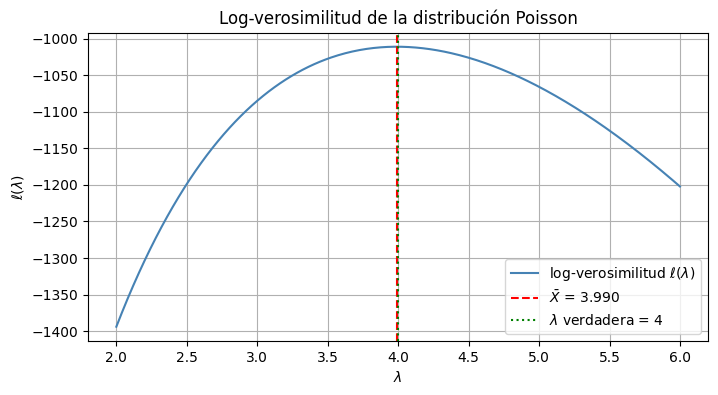

lambda verdadera        = 4
media muestral x̄        = 3.9900
lambda EMV (máx. curva) = 3.9950


In [5]:
# Generamos datos Poisson con lambda verdadera = 4
lam_v = 4
datos_pois = np.random.poisson(lam_v, size=500)
x_bar_pois = np.mean(datos_pois)

# Definimos la log-verosimilitud de la Poisson en función de lambda
def logver_poisson(lmbda, datos):
    # st.poisson.logpmf devuelve log f(x; lambda) para cada dato; sumamos
    return np.sum(st.poisson.logpmf(datos, lmbda))

# Evaluamos la log-verosimilitud en un rango de valores de lambda
lambdas = np.linspace(2, 6, 400)
logL = [logver_poisson(l, datos_pois) for l in lambdas]

# Máximo numérico de la curva
lam_emv = lambdas[np.argmax(logL)]

# Gráfica de la log-verosimilitud
plt.figure(figsize=(8, 4))
plt.plot(lambdas, logL, color='steelblue', label=r'log-verosimilitud $\ell(\lambda)$')
plt.axvline(x_bar_pois, color='red', linestyle='--', label=fr'$\bar{{X}}$ = {x_bar_pois:.3f}')
plt.axvline(lam_v, color='green', linestyle=':', label=fr'$\lambda$ verdadera = {lam_v}')
plt.title('Log-verosimilitud de la distribución Poisson')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\ell(\lambda)$')
plt.legend()
plt.show()

print(f"lambda verdadera        = {lam_v}")
print(f"media muestral x̄        = {x_bar_pois:.4f}")
print(f"lambda EMV (máx. curva) = {lam_emv:.4f}")

**Interpretación:** la curva de log-verosimilitud alcanza su máximo justo en la media muestral
$\bar{X}$, confirmando que $\hat{\lambda}_{EMV} = \bar{X}$. El estimador es el valor de $\lambda$
que hace más verosímiles los datos observados.


### Ejemplo 2 — EMV para la distribución Normal (con `scipy.optimize`)

Para la **Normal** $N(\mu,\sigma^2)$ se puede demostrar que

$$\hat{\mu}_{EMV} = \bar{X}, \qquad \hat{\sigma}^2_{EMV} = \frac{1}{n}\sum_{i=1}^n (X_i-\bar{X})^2.$$

En lugar de usar las fórmulas cerradas, vamos a **maximizar numéricamente** la log-verosimilitud
con `scipy.optimize.minimize` (minimizando la log-verosimilitud negativa) y comprobar que
coincide con las fórmulas teóricas.


In [6]:
# Datos Normales con mu = 20, sigma = 5
mu_v2, sigma_v2 = 20, 5
datos_n = np.random.normal(mu_v2, sigma_v2, size=1000)

# Log-verosimilitud NEGATIVA (la minimizamos, equivale a maximizar la log-verosimilitud)
def neg_logver_normal(params, datos):
    mu, sigma = params
    if sigma <= 0:                       # sigma debe ser positiva
        return np.inf
    return -np.sum(st.norm.logpdf(datos, loc=mu, scale=sigma))

# Punto inicial para el optimizador
inicial = [np.mean(datos_n), np.std(datos_n)]

# Optimización numérica
resultado = minimize(neg_logver_normal, inicial, args=(datos_n,), method='Nelder-Mead')
mu_emv, sigma_emv = resultado.x

# Comparación con las fórmulas teóricas de la EMV
mu_teorico = np.mean(datos_n)
sigma_teorico = np.sqrt(np.mean((datos_n - mu_teorico)**2))

print("Estimación por Máxima Verosimilitud de la Normal")
print("-" * 55)
print(f"                  Verdadero   EMV numérica   EMV fórmula")
print(f"mu       :        {mu_v2:>7}   {mu_emv:>11.4f}   {mu_teorico:>11.4f}")
print(f"sigma    :        {sigma_v2:>7}   {sigma_emv:>11.4f}   {sigma_teorico:>11.4f}")

Estimación por Máxima Verosimilitud de la Normal
-------------------------------------------------------
                  Verdadero   EMV numérica   EMV fórmula
mu       :             20       19.8291       19.8291
sigma    :              5        5.3130        5.3130


**Interpretación:** la optimización numérica con `scipy.optimize` recupera prácticamente los
mismos valores que las fórmulas teóricas y ambos se aproximan a los parámetros verdaderos
$\mu=20$ y $\sigma=5$. Esto ilustra que la EMV puede resolverse **analíticamente** cuando existe
fórmula cerrada, o **numéricamente** cuando no la hay.


## 4. Propiedades de los estimadores

Un buen estimador debe tener ciertas propiedades deseables. Estudiaremos las tres principales:
**insesgadez**, **consistencia** y **eficiencia**, cada una respaldada por una simulación.


### 4.1 Insesgadez

Un estimador $\hat{\theta}$ es **insesgado** si su valor esperado coincide con el parámetro:

$$E(\hat{\theta}) = \theta.$$

En promedio (sobre muchas muestras) "acierta" al valor verdadero, sin sobreestimar ni subestimar.

Comprobaremos por simulación con **10,000 muestras** que:
- La media muestral $\bar{X}$ es insesgada: $E(\bar{X}) \approx \mu$.
- La varianza muestral $s^2 = \frac{1}{n-1}\sum (X_i-\bar{X})^2$ es insesgada: $E(s^2)\approx\sigma^2$.
- La **desviación estándar muestral** $s$ es **sesgada**: $E(s) < \sigma$ (subestima).


In [7]:
# Parámetros verdaderos
mu_real, sigma_real = 5, 2
sigma2_real = sigma_real**2
n_muestra = 10          # tamaño de cada muestra
N_sim = 10000           # número de muestras simuladas

medias = np.empty(N_sim)
var_muestrales = np.empty(N_sim)     # s^2 con divisor (n-1)  -> ddof=1
desv_muestrales = np.empty(N_sim)    # s = sqrt(s^2)

for i in range(N_sim):
    x = np.random.normal(mu_real, sigma_real, n_muestra)
    medias[i] = np.mean(x)
    var_muestrales[i] = np.var(x, ddof=1)          # varianza insesgada
    desv_muestrales[i] = np.std(x, ddof=1)         # desviación estándar

print(f"E[x̄]  ≈ {medias.mean():.4f}   (mu verdadera = {mu_real})            -> INSESGADO")
print(f"E[s²]  ≈ {var_muestrales.mean():.4f}   (sigma² verdadera = {sigma2_real})       -> INSESGADO")
print(f"E[s]   ≈ {desv_muestrales.mean():.4f}   (sigma verdadera = {sigma_real})        -> SESGADO (subestima)")

E[x̄]  ≈ 5.0004   (mu verdadera = 5)            -> INSESGADO
E[s²]  ≈ 4.0106   (sigma² verdadera = 4)       -> INSESGADO
E[s]   ≈ 1.9475   (sigma verdadera = 2)        -> SESGADO (subestima)


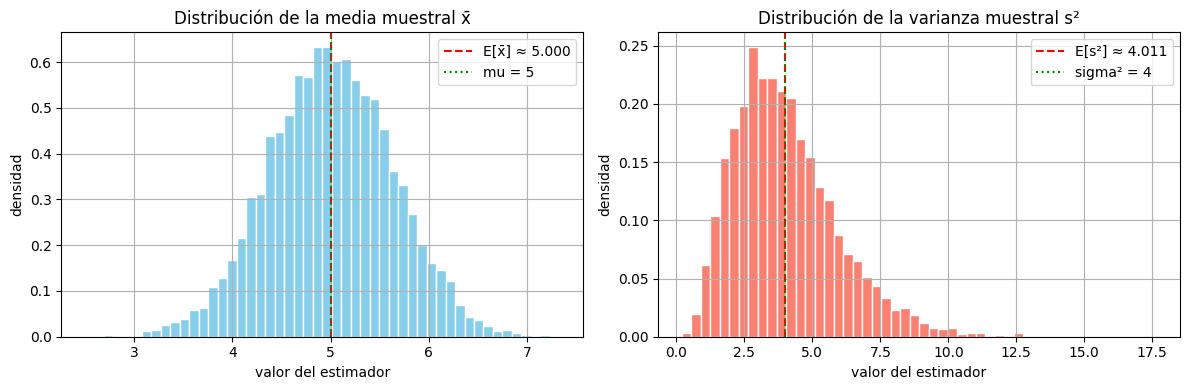

In [8]:
# Visualizamos las distribuciones de los estimadores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Media muestral
axes[0].hist(medias, bins=50, color='skyblue', edgecolor='white', density=True)
axes[0].axvline(medias.mean(), color='red', linestyle='--', label=f'E[x̄] ≈ {medias.mean():.3f}')
axes[0].axvline(mu_real, color='green', linestyle=':', label=f'mu = {mu_real}')
axes[0].set_title('Distribución de la media muestral x̄')
axes[0].set_xlabel('valor del estimador'); axes[0].set_ylabel('densidad'); axes[0].legend()

# Varianza muestral
axes[1].hist(var_muestrales, bins=50, color='salmon', edgecolor='white', density=True)
axes[1].axvline(var_muestrales.mean(), color='red', linestyle='--', label=f'E[s²] ≈ {var_muestrales.mean():.3f}')
axes[1].axvline(sigma2_real, color='green', linestyle=':', label=f'sigma² = {sigma2_real}')
axes[1].set_title('Distribución de la varianza muestral s²')
axes[1].set_xlabel('valor del estimador'); axes[1].set_ylabel('densidad'); axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretación:** el promedio de $\bar{X}$ y de $s^2$ sobre las 10,000 muestras coincide con
$\mu$ y $\sigma^2$ respectivamente, confirmando que son **insesgados**. En cambio, $s$ subestima
sistemáticamente a $\sigma$ (por la desigualdad de Jensen aplicada a la raíz, que es cóncava),
por lo que la desviación estándar muestral es un estimador **sesgado**.


### 4.2 Consistencia

Un estimador es **consistente** si converge (en probabilidad) al parámetro verdadero conforme el
tamaño de muestra crece:

$$\hat{\theta}_n \xrightarrow{P} \theta \quad \text{cuando } n \to \infty.$$

En la práctica esto significa que su **error** (medido por el error cuadrático medio, MSE, o por
su varianza) **disminuye** al aumentar $n$. Lo mostramos gráficamente.


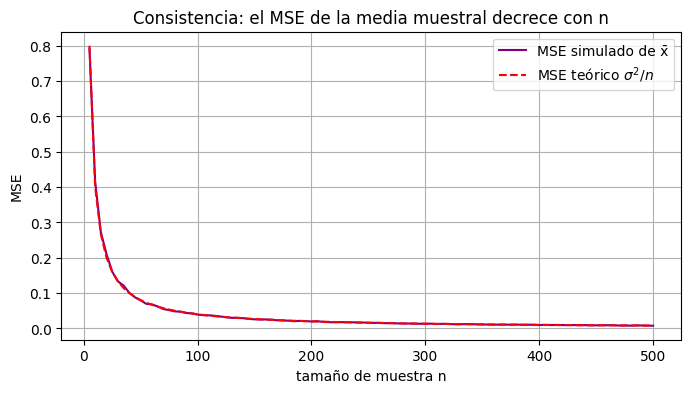

MSE con n=5   : 0.7920
MSE con n=500 : 0.0077


In [9]:
# Estudiamos cómo cambia el MSE de la media muestral al aumentar n
mu_c = 5
sigma_c = 2
tamanos = np.arange(5, 505, 5)     # n de 5 a 500
N_rep = 2000                        # repeticiones por cada n
mse_por_n = []

for n_c in tamanos:
    estimaciones = np.mean(np.random.normal(mu_c, sigma_c, size=(N_rep, n_c)), axis=1)
    mse = np.mean((estimaciones - mu_c)**2)     # error cuadrático medio
    mse_por_n.append(mse)

mse_por_n = np.array(mse_por_n)

plt.figure(figsize=(8, 4))
plt.plot(tamanos, mse_por_n, color='purple', label='MSE simulado de x̄')
plt.plot(tamanos, sigma_c**2 / tamanos, 'r--', label=r'MSE teórico $\sigma^2/n$')
plt.title('Consistencia: el MSE de la media muestral decrece con n')
plt.xlabel('tamaño de muestra n')
plt.ylabel('MSE')
plt.legend()
plt.show()

print(f"MSE con n=5   : {mse_por_n[0]:.4f}")
print(f"MSE con n=500 : {mse_por_n[-1]:.4f}")

**Interpretación:** el error cuadrático medio de $\bar{X}$ decrece hacia cero conforme aumenta
$n$, siguiendo la curva teórica $\sigma^2/n$. Esto confirma que la media muestral es un estimador
**consistente**: con más datos, la estimación se vuelve cada vez más precisa.


### 4.3 Eficiencia

Entre dos estimadores **insesgados** del mismo parámetro, el más **eficiente** es el que tiene
**menor varianza** (menor dispersión alrededor del valor verdadero).

Para datos **Normales**, tanto la media muestral $\bar{X}$ como la mediana muestral son
estimadores insesgados de $\mu$. Compararemos sus varianzas: la teoría indica que la mediana es
aproximadamente un 57% más variable ($\text{Var}(\text{mediana}) \approx \frac{\pi}{2}\text{Var}(\bar{X})$),
por lo que **la media es más eficiente**.


In [10]:
mu_e, sigma_e = 0, 1
n_e = 30
N_e = 20000

medias_e = np.empty(N_e)
medianas_e = np.empty(N_e)

for i in range(N_e):
    x = np.random.normal(mu_e, sigma_e, n_e)
    medias_e[i] = np.mean(x)
    medianas_e[i] = np.median(x)

var_media = np.var(medias_e)
var_mediana = np.var(medianas_e)

print(f"Varianza de la media muestral   : {var_media:.5f}")
print(f"Varianza de la mediana muestral : {var_mediana:.5f}")
print(f"Eficiencia relativa (mediana/media): {var_mediana/var_media:.3f}  (teórico ≈ {np.pi/2:.3f})")
print("-> La MEDIA es más eficiente porque tiene MENOR varianza.")

Varianza de la media muestral   : 0.03366
Varianza de la mediana muestral : 0.05062
Eficiencia relativa (mediana/media): 1.504  (teórico ≈ 1.571)
-> La MEDIA es más eficiente porque tiene MENOR varianza.


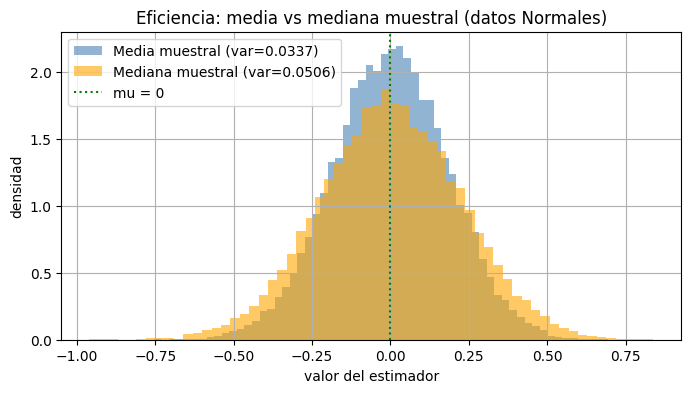

In [11]:
# Comparamos visualmente la dispersión de ambos estimadores
plt.figure(figsize=(8, 4))
plt.hist(medias_e, bins=60, alpha=0.6, color='steelblue', density=True,
         label=f'Media muestral (var={var_media:.4f})')
plt.hist(medianas_e, bins=60, alpha=0.6, color='orange', density=True,
         label=f'Mediana muestral (var={var_mediana:.4f})')
plt.axvline(mu_e, color='green', linestyle=':', label=f'mu = {mu_e}')
plt.title('Eficiencia: media vs mediana muestral (datos Normales)')
plt.xlabel('valor del estimador')
plt.ylabel('densidad')
plt.legend()
plt.show()

**Interpretación:** ambos estimadores están centrados en $\mu=0$ (son insesgados), pero la
distribución de la **media muestral es más concentrada** (menor varianza) que la de la mediana.
Por lo tanto, para datos Normales la media muestral es el estimador **más eficiente**.


## 5. Intervalos de confianza

Un **estimador puntual** da un solo número, pero no informa sobre su precisión. Un **intervalo de
confianza (IC)** proporciona un **rango de valores plausibles** para el parámetro, junto con un
**nivel de confianza** $(1-\alpha)\times 100\%$ (típicamente 95%).

**Interpretación correcta:** si repitiéramos el muestreo muchas veces y construyéramos un IC cada
vez, aproximadamente el $(1-\alpha)\times100\%$ de esos intervalos contendría al parámetro verdadero.


### 5.1 IC para la media con $\sigma$ conocida (distribución Normal)

Cuando la desviación estándar poblacional $\sigma$ es **conocida**, el IC para $\mu$ es:

$$\bar{X} \pm z_{1-\alpha/2}\,\frac{\sigma}{\sqrt{n}},$$

donde $z_{1-\alpha/2}$ es el cuantil de la Normal estándar (por ejemplo $1.96$ para el 95%).


In [12]:
# Ejemplo: peso medio de un producto. sigma conocida = 4 gramos.
sigma_conocida = 4
n_ic = 40
mu_real_ic = 100
muestra_ic = np.random.normal(mu_real_ic, sigma_conocida, n_ic)

x_barra = np.mean(muestra_ic)
alpha = 0.05
z = st.norm.ppf(1 - alpha/2)                 # z_{0.975} ≈ 1.96
error_est = z * sigma_conocida / np.sqrt(n_ic)

ic_inf = x_barra - error_est
ic_sup = x_barra + error_est

print(f"Media muestral x̄ = {x_barra:.4f}")
print(f"z_(0.975) = {z:.4f}")
print(f"IC 95% para mu : [{ic_inf:.4f} , {ic_sup:.4f}]")

Media muestral x̄ = 99.9965
z_(0.975) = 1.9600
IC 95% para mu : [98.7569 , 101.2361]


**Frase explicativa:** Con un 95% de confianza, el peso medio verdadero del producto se
encuentra entre **{:.2f} g** y **{:.2f} g**. Este intervalo fue construido con un procedimiento
que acierta el 95% de las veces.

*(Los valores exactos se imprimen arriba.)*


### 5.2 IC para la media con $\sigma$ desconocida (distribución t de Student)

En la práctica $\sigma$ casi nunca se conoce. La estimamos con la desviación muestral $s$ y usamos
la distribución **t de Student** con $n-1$ grados de libertad:

$$\bar{X} \pm t_{1-\alpha/2,\;n-1}\,\frac{s}{\sqrt{n}}.$$


In [13]:
# Ejemplo: tiempos de espera (minutos) de una muestra pequeña
tiempos = np.array([12.1, 10.8, 13.5, 11.2, 12.9, 10.1, 14.0, 11.7, 12.3, 13.1, 10.9, 12.6])
n_t = len(tiempos)

x_barra_t = np.mean(tiempos)
s = np.std(tiempos, ddof=1)                   # desviación muestral (divisor n-1)
alpha = 0.05
t_crit = st.t.ppf(1 - alpha/2, df=n_t - 1)    # cuantil t con n-1 gl
error_t = t_crit * s / np.sqrt(n_t)

ic_inf_t = x_barra_t - error_t
ic_sup_t = x_barra_t + error_t

print(f"n = {n_t}")
print(f"Media muestral x̄ = {x_barra_t:.4f}")
print(f"Desviación muestral s = {s:.4f}")
print(f"t crítico ({n_t-1} gl) = {t_crit:.4f}")
print(f"IC 95% para mu : [{ic_inf_t:.4f} , {ic_sup_t:.4f}]")

n = 12
Media muestral x̄ = 12.1000
Desviación muestral s = 1.1909
t crítico (11 gl) = 2.2010
IC 95% para mu : [11.3434 , 12.8566]


**Frase explicativa:** Con un 95% de confianza, el tiempo medio de espera verdadero está entre
los límites calculados arriba. Al usar la distribución **t de Student**, el intervalo es
ligeramente más ancho que con la Normal, reflejando la incertidumbre adicional por estimar
$\sigma$ a partir de la muestra.


### 5.3 IC para una proporción

Para una **proporción** $p$ (por ejemplo, el porcentaje de personas que aprueban algo), el
estimador es $\hat{p} = x/n$ y el IC aproximado (por el TCL) es:

$$\hat{p} \pm z_{1-\alpha/2}\,\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}.$$


In [14]:
# Ejemplo: encuesta de opinión. De n = 500 encuestados, 320 aprueban una propuesta.
n_enc = 500
x_aprueban = 320
p_hat = x_aprueban / n_enc

alpha = 0.05
z = st.norm.ppf(1 - alpha/2)
error_p = z * np.sqrt(p_hat * (1 - p_hat) / n_enc)

ic_inf_p = p_hat - error_p
ic_sup_p = p_hat + error_p

print(f"Proporción muestral p̂ = {p_hat:.4f}  ({p_hat*100:.1f}%)")
print(f"Margen de error = {error_p:.4f}  ({error_p*100:.2f} puntos porcentuales)")
print(f"IC 95% para p : [{ic_inf_p:.4f} , {ic_sup_p:.4f}]  = [{ic_inf_p*100:.1f}% , {ic_sup_p*100:.1f}%]")

Proporción muestral p̂ = 0.6400  (64.0%)
Margen de error = 0.0421  (4.21 puntos porcentuales)
IC 95% para p : [0.5979 , 0.6821]  = [59.8% , 68.2%]


**Frase explicativa:** Con un 95% de confianza, la proporción verdadera de la población que
aprueba la propuesta se encuentra entre **{:.1f}%** y **{:.1f}%**. Es la típica lectura de una
encuesta con su "margen de error".


## 6. Visualización de la cobertura del intervalo de confianza

Para entender la **interpretación frecuentista** del IC, simulamos **100 muestras** de una
población Normal con media conocida $\mu=50$. Para cada muestra construimos un IC del 95% y
verificamos qué porcentaje de los intervalos contiene realmente a $\mu$. La teoría dice que debe
ser cercano al **95%**.


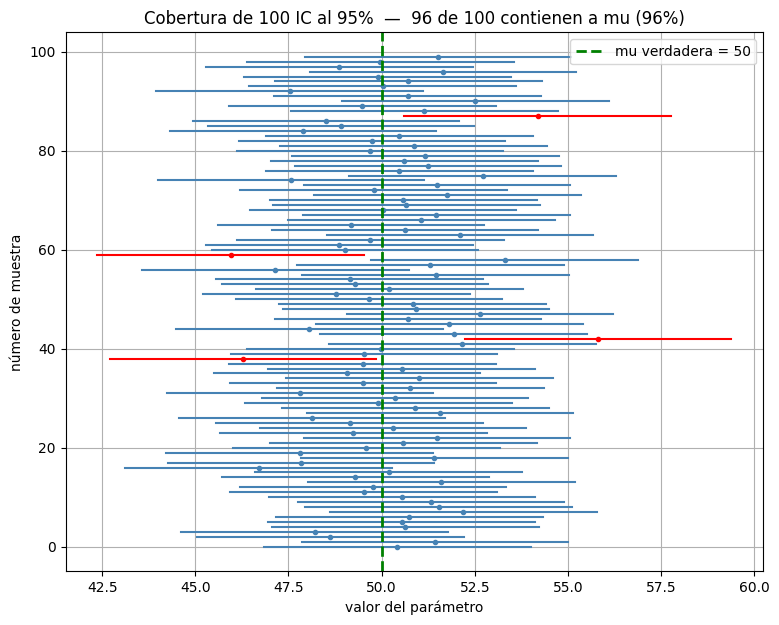

Intervalos que contienen a mu : 96 de 100  (96%)
Cobertura teórica esperada    : 95%


In [15]:
# Población: Normal con mu = 50, sigma = 10
mu_pob = 50
sigma_pob = 10
n_cob = 30
N_intervalos = 100
alpha = 0.05
z = st.norm.ppf(1 - alpha/2)

plt.figure(figsize=(9, 7))
contiene = 0

for i in range(N_intervalos):
    x = np.random.normal(mu_pob, sigma_pob, n_cob)
    xb = np.mean(x)
    err = z * sigma_pob / np.sqrt(n_cob)
    inf, sup = xb - err, xb + err

    # ¿El intervalo contiene a mu?
    if inf <= mu_pob <= sup:
        contiene += 1
        color = 'steelblue'      # contiene al parámetro
    else:
        color = 'red'            # NO contiene al parámetro

    plt.plot([inf, sup], [i, i], color=color, linewidth=1.5)
    plt.plot(xb, i, 'o', color=color, markersize=3)

plt.axvline(mu_pob, color='green', linestyle='--', linewidth=2, label=f'mu verdadera = {mu_pob}')
plt.title(f'Cobertura de 100 IC al 95%  —  {contiene} de {N_intervalos} contienen a mu '
          f'({contiene}%)')
plt.xlabel('valor del parámetro')
plt.ylabel('número de muestra')
plt.legend(loc='upper right')
plt.show()

print(f"Intervalos que contienen a mu : {contiene} de {N_intervalos}  ({contiene}%)")
print(f"Cobertura teórica esperada    : {int((1-alpha)*100)}%")

**Interpretación:** aproximadamente el 95% de los intervalos (en azul) contienen a la media
verdadera $\mu=50$, mientras que unos pocos (en rojo) no la contienen. Esto ilustra el
significado correcto de la "confianza del 95%": **no** es la probabilidad de que $\mu$ esté en un
intervalo particular, sino la proporción de intervalos que, a la larga, capturan el parámetro.


## 7. Conclusión

En este notebook recorrimos las ideas centrales de la **Estadística Inferencial**:

- **Estimadores puntuales:** reglas que resumen la muestra en un único valor que aproxima al
  parámetro poblacional desconocido. Al depender de la muestra, son variables aleatorias.
- **Método de los momentos:** técnica sencilla que iguala momentos teóricos con muestrales; la
  aplicamos a las distribuciones Exponencial y Normal.
- **Máxima Verosimilitud (EMV):** elige el parámetro que hace más plausibles los datos observados.
  La resolvimos gráficamente (Poisson) y numéricamente con `scipy.optimize` (Normal), obteniendo
  estimadores muy cercanos a los valores verdaderos.
- **Propiedades de los estimadores:** verificamos por simulación la **insesgadez** ($E[\bar X]=\mu$,
  $E[s^2]=\sigma^2$, mientras que $s$ es sesgado), la **consistencia** (el MSE decrece como
  $\sigma^2/n$) y la **eficiencia** (la media es más precisa que la mediana en datos Normales).
- **Intervalos de confianza:** construimos ICs para la media (con $\sigma$ conocida y desconocida)
  y para una proporción, siempre acompañados de su interpretación en lenguaje claro.
- **Cobertura:** la simulación de 100 intervalos mostró visualmente por qué un IC del 95% captura
  al parámetro aproximadamente el 95% de las veces.

En conjunto, estos conceptos nos permiten no solo **estimar** parámetros desconocidos, sino
también **cuantificar la incertidumbre** de nuestras estimaciones, que es el corazón de la
inferencia estadística.


## 8. Bibliografía

- Rincón, L. (2014). *Introducción a la probabilidad*. Facultad de Ciencias, UNAM.
- Ross, S. M. (2014). *Introduction to Probability and Statistics for Engineers and Scientists* (5.ª ed.). Academic Press.
- Mood, A. M., Graybill, F. A. & Boes, D. C. (1974). *Introduction to the Theory of Statistics* (3.ª ed.). McGraw-Hill.
- Mendenhall, W., Beaver, R. J. & Beaver, B. M. (2010). *Introducción a la probabilidad y estadística* (13.ª ed.). Cengage Learning.
